# [1교시]

- **코퍼스(corpus)**: 분석 대상이 되는 텍스트 전체 집합입니다.
- **문서(document)**: 코퍼스 안의 한 단위 텍스트입니다.
- **문장(sentence)**: 문서 내부의 문장 단위입니다.
- **토큰(token)**: 토큰화(tokenization) 후 얻는 최소 분석 단위입니다. 보통 단어, 형태소, 서브워드가 될 수 있습니다.
- **타입(type)**: 서로 다른 고유 토큰의 개수입니다.
- **어휘(vocabulary)**: 코퍼스에 등장한 모든 고유 토큰의 집합입니다.
- **토큰 수(token count)**: 문서 또는 코퍼스 전체에서 실제 등장한 토큰의 총 개수입니다.
- **문서 길이(document length)**: 한 문서에 포함된 토큰의 수입니다.
- **희소성(sparsity)**: 전체 가능한 단어 공간에 비해 실제 등장한 값이 매우 적은 정도입니다.

여기서 가장 중요한 구분은 다음입니다.

- **토큰 수**는 등장 횟수의 합입니다.
- **타입 수**는 중복을 제거한 고유 단어의 수입니다.

- $d_1$: `나는 자연어 처리를 공부한다`
- $d_2$: `자연어 처리는 재미있다`
- $d_3$: `나는 데이터 분석과 자연어 처리를 함께 배운다`

공백 기준으로 단순 토큰화를 한다고 가정하면 다음과 같습니다.

- $d_1$ 토큰: `[나는, 자연어, 처리를, 공부한다]`
- $d_2$ 토큰: `[자연어, 처리는, 재미있다]`
- $d_3$ 토큰: `[나는, 데이터, 분석과, 자연어, 처리를, 함께, 배운다]`

$$
\text{코퍼스} \rightarrow \text{문서 집합} \rightarrow \text{문장 집합} \rightarrow \text{토큰 시퀀스}
$$

- $\rightarrow$: 상위 구조가 하위 구조를 포함한다는 뜻입니다.
- 코퍼스는 여러 문서로 이루어집니다.
- 각 문서는 여러 문장으로 이루어집니다.
- 각 문장은 토큰들의 순서열입니다.

실무에서는 이 구조를 다음처럼 다룹니다.

- 문서 단위 분석: 감성분석, 분류, 토픽모델링
- 문장 단위 분석: 번역, 요약, 질의응답
- 토큰 단위 분석: 언어모델, 다음 토큰 예측, 형태소 분석

문서 $d_i$의 길이를 토큰 수로 정의하면,

$$
\ell(d_i) = \text{문서 } d_i \text{에 포함된 토큰의 수}
$$


예제 코퍼스에서 각 문서 길이는 다음과 같습니다.

- $\ell(d_1) = 4$
- $\ell(d_2) = 3$
- $\ell(d_3) = 7$

코퍼스 전체 토큰 수는 모든 문서 길이의 합입니다.

$$
T = \sum_{i=1}^{N} \ell(d_i)
$$

예제에서는

$$
T = 4 + 3 + 7 = 14
$$

평균 문서 길이는 다음과 같습니다.

$$
\mu_\ell = \frac{1}{N}\sum_{i=1}^{N}\ell(d_i)
$$

예제에서는

$$
\mu_\ell = \frac{4+3+7}{3} = \frac{14}{3} \approx 4.67
$$

즉, 한 문서의 평균 길이는 약 4.67토큰입니다.

문서 길이의 분산은 다음과 같습니다.

$$
\sigma_\ell^2 = \frac{1}{N}\sum_{i=1}^{N}(\ell(d_i)-\mu_\ell)^2
$$

- $\sigma_\ell^2$: 문서 길이의 분산입니다.
- $\ell(d_i)-\mu_\ell$: 각 문서 길이와 평균의 차이입니다.
- $()^2$: 차이를 제곱해서 음수와 양수를 모두 양수로 바꿉니다.
- $\frac{1}{N}$: 전체 문서 수로 나누어 평균 제곱 편차를 구합니다.

예제의 각 편차는 다음과 같습니다.

- $4 - 14/3 = -2/3$
- $3 - 14/3 = -5/3$
- $7 - 14/3 = 7/3$

따라서

$$
\sigma_\ell^2 = \frac{1}{3}\left(\left(-\frac{2}{3}\right)^2 + \left(-\frac{5}{3}\right)^2 + \left(\frac{7}{3}\right)^2\right) = \frac{26}{9}
$$

즉, 분산은 26/9입니다. 분산이 클수록 문서 길이가 평균에서 많이 퍼져 있다는 뜻입니다.

표준편차는 분산의 제곱근입니다.

$$
\sigma_\ell = \sqrt{\sigma_\ell^2} = \sqrt{\frac{26}{9}} = \frac{\sqrt{26}}{3}
$$

기호 설명:

- $\sigma_\ell$: 문서 길이의 표준편차입니다.
- $\sqrt{\,}$: 제곱근입니다.
- 분산의 제곱근을 취해 원래 단위와 같은 크기의 흩어짐 정도를 얻습니다.

즉, 표준편차가 클수록 문서 길이의 변동이 크다는 뜻입니다.

## 어휘 수와 타입/토큰 비율(TTR)
### 어휘 집합

코퍼스의 고유 토큰을 모으면 다음과 같습니다.

$$
V = \{나는, 자연어, 처리를, 공부한다, 처리는, 재미있다, 데이터, 분석과, 함께, 배운다\}
$$

어휘 수는

$$
|V| = 10
$$


타입/토큰 비율(Type-Token Ratio, TTR)은 다음과 같습니다.

$$
\mathrm{TTR} = \frac{|V|}{T}
$$

기호 설명:

- $\mathrm{TTR}$: 타입/토큰 비율입니다.
- $|V|$: 고유 토큰 수입니다.
- $T$: 전체 토큰 수입니다.

예제에서는

$$
\mathrm{TTR} = \frac{10}{14} \approx 0.714
$$

여기서 10은 고유 토큰 수, 14는 전체 토큰 수입니다. 비율이 약 0.714이므로 전체 토큰의 상당 부분이 서로 다른 단어로 이루어져 있음을 뜻합니다.

### TTR의 한계

TTR은 문서가 길어질수록 보통 감소합니다. 왜냐하면 문서가 길어지면 새로운 단어가 계속 나오더라도 중복 등장도 함께 늘어나기 때문입니다.

즉, TTR만으로 코퍼스의 어휘 풍부도를 비교하면 문서 길이 차이의 영향을 받습니다. 그래서 실무에서는 다음과 같은 보조 지표도 함께 봅니다.

- 고유 단어 수의 증가 추이
- 문서 길이 보정된 지표
- 상위 빈도 단어 비율

## 토큰 빈도 정의

어떤 토큰 $w$의 전체 빈도는 다음과 같이 정의합니다.

$$
f(w) = \sum_{i=1}^{N} \mathrm{count}(w \text{ in } d_i)
$$

기호 설명:

- $f(w)$: 토큰 $w$의 전체 등장 횟수입니다.
- $w$: 관심 있는 토큰입니다.
- $\mathrm{count}(w \text{ in } d_i)$: $i$번째 문서에서 토큰 $w$가 몇 번 나왔는지 세는 값입니다.
- $\sum_{i=1}^{N}$: 모든 문서를 합산한다는 뜻입니다.

즉, 각 문서에서의 등장 횟수를 모두 더한 것이 전체 빈도입니다

### 예제 코퍼스에서 빈도 계산

토큰별 빈도를 계산하면 다음과 같습니다.

- `나는`: 2
- `자연어`: 3
- `처리를`: 2
- `공부한다`: 1
- `처리는`: 1
- `재미있다`: 1
- `데이터`: 1
- `분석과`: 1
- `함께`: 1
- `배운다`: 1

### 빈도분포가 중요한 이유

토큰 빈도 분포를 보면 다음을 알 수 있습니다.

- 매우 자주 나오는 단어: 불용어 후보, 일반어, 조사
- 아주 적게 나오는 단어: 희귀어, 고유명사, 오타 가능성
- 분포의 꼬리: 장문의 코퍼스에서는 희귀어가 매우 많음

이 정보는 이후 다음과 같은 작업에 쓰입니다.

- 불용어 제거
- 희귀어 처리
- 어휘 사전 구축
- 언어모델 토크나이저 학습

문장 길이 또한 중요한 통계입니다. 문장 길이 $s_i$를 한 문장에 포함된 토큰 수라고 하면,

$$
\mu_s = \frac{1}{M}\sum_{i=1}^{M}s_i
$$

기호 설명:

- $\mu_s$: 문장 길이의 평균입니다.
- $M$: 문장 수입니다.
- $s_i$: $i$번째 문장의 길이입니다.
- $\sum$: 모든 문장의 길이를 더합니다.

즉, 문장 길이의 총합을 문장 수로 나눈 값입니다.

문장 길이 분포는 다음에서 중요합니다.

- 번역 모델 입력 길이
- 요약 모델 청크 분할
- 질의응답 데이터셋 문맥 길이
- 감성분석에서 짧은 리뷰와 긴 리뷰의 차이

In [1]:
# 코퍼스 및 기본 토큰화
%conda install nltk

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


C:\miniconda\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
C:\miniconda\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda




In [2]:
from nltk.tokenize import word_tokenize
import numpy as np

In [3]:
# 코퍼스 정의
corpus = {
    "나는 자연어 처리를 공부한다",
    "자연어 처리는 재미있다",
    "나는 데이터 분석과 자연어 처리를 함께 공부한다"
}
# 공백을 기준으로 단순 토큰화
tokenized_corpus = [ doc.split() for doc in corpus ]
tokenized_corpus

[['나는', '자연어', '처리를', '공부한다'],
 ['자연어', '처리는', '재미있다'],
 ['나는', '데이터', '분석과', '자연어', '처리를', '함께', '공부한다']]

In [4]:
# 각 문서의 길이
doc_lenghs = [ len(token) for token in tokenized_corpus]

N =     len(corpus)     # 총 문서 수 
T =     sum(doc_lenghs) # 코퍼스 전체 토큰수

# 평균 문서의 수
mean_legth = T / N
print(mean_legth)

4.666666666666667


# [2교시]

### 어휘 수와 타입 / 토큰 비율(TTR)

In [5]:
# 어휘 집합
vocabulary = set()
for tokens in tokenized_corpus:
    vocabulary.update(tokens)
print(f'vocabulary : {vocabulary}')
V_size = len(vocabulary)
print(f'어휘수 : {V_size}')
# TTR
TTR = V_size / T
print(f'타입/토큰비율 : {TTR}')

vocabulary : {'재미있다', '함께', '데이터', '처리를', '공부한다', '처리는', '분석과', '나는', '자연어'}
어휘수 : 9
타입/토큰비율 : 0.6428571428571429


In [6]:
# 토큰 빈도와 단어 빈도분포, 희소성
from collections import Counter
# 전체 토큰을 하나의 리스트로 합침
all_tokens = [token for tokens in tokenized_corpus for token in tokens ]
token_freq = Counter(all_tokens)
print(f'토큰 빈도 : {token_freq}')

# 문서-단어 행렬에서 관측값 계산 - 각 문서내의 고유 단어 등장 수 합계
non_zero_cells = sum(len(set(tokens)) for tokens in tokenized_corpus)
total_cells = N * V_size    # 문서 수 * 어휘 수(|V|)
density = non_zero_cells / total_cells
sparsity = 1 - density
print(f'희소성 : {sparsity:.4f}')
print(f'문서-단어 행렬 전체 칸 수 : {total_cells}')
print(f'값이 있는 칸 수 : {non_zero_cells}')
print(f'밀도 : {density : .4f}')

토큰 빈도 : Counter({'자연어': 3, '나는': 2, '처리를': 2, '공부한다': 2, '처리는': 1, '재미있다': 1, '데이터': 1, '분석과': 1, '함께': 1})
희소성 : 0.4815
문서-단어 행렬 전체 칸 수 : 27
값이 있는 칸 수 : 14
밀도 :  0.5185


In [7]:
# 이상한 나라의 엘리스
import nltk
import matplotlib.pylab as plt
from nltk.corpus import gutenberg
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords #불용어

# 데이터 다운로드
nltk.download('gutenberg')
nltk.download('stopwords')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\최지용\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\최지용\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
# 이상한 나라의 엘리스 코퍼스 로드
doc_alice = gutenberg.raw('carroll-alice.txt')

# 정규식을 이용해서 3글자 이상 단어 추출 및 소문자
tokenizer = RegexpTokenizer(r"[\w']{3,}")
reg_tokens_alice = tokenizer.tokenize(doc_alice.lower())

# 불용어 제거
english_stops = stopwords.words('english')
result_alice = [word for word in reg_tokens_alice if word not in english_stops]

# 토큰빈도 집계
alice_word_count = Counter(result_alice)
print(f'사용된 고유 단어 수 : {len(alice_word_count)}')

사용된 고유 단어 수 : 2671


In [9]:
# 상위 20개 단어 추출
top_20_words = alice_word_count.most_common(20)
print(f'상위 20개 고빈도 단어 : {top_20_words}')

상위 20개 고빈도 단어 : [('said', 462), ('alice', 385), ('little', 128), ('one', 98), ('know', 88), ('like', 85), ('went', 83), ('would', 78), ('could', 77), ('thought', 74), ('time', 71), ('queen', 68), ('see', 67), ('king', 61), ('began', 58), ('turtle', 57), ("'and", 56), ('way', 56), ('mock', 56), ('quite', 55)]


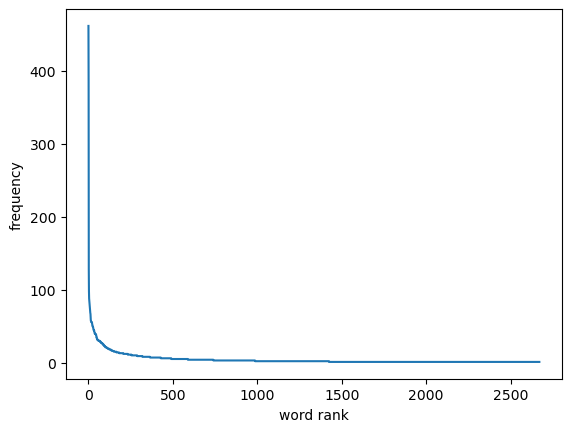

In [10]:
all_requenceis = sorted(list(alice_word_count.values()), reverse=True)
plt.plot(all_requenceis)
plt.xlabel('word rank')
plt.ylabel('frequency')
plt.show()

- **토큰화(tokenization)**: 원문 텍스트를 토큰(token)이라는 작은 단위로 나누는 과정입니다.
- **토큰(token)**: 토큰화 후 얻는 최소 분석 단위입니다. 단어, 형태소, 서브워드가 될 수 있습니다.
- **정규화(normalization)**: 표기 차이로 인한 불필요한 변동을 줄이기 위해 텍스트를 일정한 형태로 맞추는 과정입니다.
- **소문자화(lowercasing)**: 대문자를 소문자로 바꾸는 처리입니다.
- **불용어(stopword)**: 분석 목적과 무관하게 자주 등장하는 단어입니다.
- **표제어(lemmatization)**: 단어의 기본형으로 되돌리는 처리입니다.
- **어간 추출(stemming)**: 어근 또는 어간 수준까지 단어를 잘라 내는 처리입니다.
- **유니코드 정규화(unicode normalization)**: 같은 글자가 다른 코드로 표현되는 문제를 정리하는 과정입니다.
- **서브워드(subword)**: 단어보다 작은, 하지만 문자보다 큰 단위입니다.

가장 중요한 구분은 다음입니다.

- 토큰화는 **쪼개는 작업**입니다.
- 정규화는 **형태를 맞추는 작업**입니다.

## 3. 왜 토큰화와 정규화가 필요한가

자연어는 같은 의미라도 표현 방식이 매우 다양합니다.

예를 들어 다음 문자열은 모두 비슷한 의미를 가질 수 있습니다.

- `NLP`
- `nlp`
- `N.L.P.`
- `NLP!`

사람은 이 표현들을 거의 같은 것으로 볼 수 있지만, 컴퓨터는 문자 그대로 비교하면 서로 다른 문자열로 봅니다. 따라서 토큰화와 정규화가 필요합니다.

이 단계가 중요한 이유는 다음과 같습니다.

- 같은 의미를 같은 형태로 모을 수 있다.
- 어휘 크기를 줄일 수 있다.
- 희소성을 줄일 수 있다.
- 후속 단계인 TF, DF, TF-IDF, 분류, 토픽모델링의 품질이 좋아진다.

## 4. 예제 텍스트 먼저 보기

설명을 위해 다음 아주 작은 원문을 사용하겠습니다.

$$
X = \text{`오늘은 NLP를 공부한다! NLP는 재미있다.`}
$$

기호 설명:

- $X$: 분석할 원문 텍스트입니다.
- `오늘은 NLP를 공부한다! NLP는 재미있다.`: 예제 원문입니다.

이 예제를 사용하면 토큰화와 정규화가 어떻게 결과를 바꾸는지 직접 확인할 수 있습니다.

## 5. 토큰화의 기본 개념

토큰화는 원문 $X$를 토큰 시퀀스로 바꾸는 과정입니다.

$$
X \rightarrow (t_1, t_2, \dots, t_m)
$$

기호 설명:

- $X$: 원문 텍스트입니다.
- $\rightarrow$: 변환을 뜻합니다.
- $t_1, t_2, \dots, t_m$: 토큰들입니다.
- $m$: 토큰의 개수입니다.

즉, 한 문장을 여러 개의 작은 단위로 나누는 것입니다.

### 5.1 공백 기반 토큰화

가장 단순한 토큰화는 공백 기준 분리입니다.

예제 원문에 공백 기준을 적용하면 다음과 같습니다.

- `오늘은`
- `NLP를`
- `공부한다!`
- `NLP는`
- `재미있다.`

이 방식은 쉽지만 문제가 있습니다.

- `공부한다!`와 `공부한다`를 다르게 본다.
- `재미있다.`와 `재미있다`를 다르게 본다.
- 쉼표, 마침표, 느낌표 같은 구두점이 토큰에 붙어 남는다.

따라서 실제 NLP에서는 공백 기반만으로는 부족한 경우가 많습니다.

### 5.2 구두점 제거 토큰화

구두점을 먼저 제거한 뒤 토큰화할 수 있습니다.

예제 원문에서 느낌표와 마침표를 제거하면

$$
X' = \text{`오늘은 NLP를 공부한다 NLP는 재미있다`}
$$

기호 설명:

- $X'$: 구두점이 제거된 텍스트입니다.
- 원래 텍스트에서 `!`, `.` 같은 문자를 제거한 결과입니다.

그 후 공백 기준으로 나누면 다음 토큰을 얻습니다.

- `오늘은`
- `NLP를`
- `공부한다`
- `NLP는`
- `재미있다`

이제 구두점에 의한 불필요한 차이는 줄어듭니다.

## 6. 토큰 개수와 수식 표현

토큰화 결과 토큰 수는 다음처럼 셉니다.

$$
m = |T(X)|
$$

기호 설명:

- $m$: 토큰 수입니다.
- $T(X)$: 원문 $X$를 토큰화한 결과입니다.
- $|T(X)|$: 토큰 시퀀스의 길이, 즉 토큰 개수입니다.

예제 원문을 공백 기반으로 나누면 토큰 수는 5개입니다.

$$
m = 5
$$

기호 설명:

- $m$: 토큰 개수입니다.

즉, 하나의 원문이 토큰화되면 토큰 수가 정해집니다.

# [3교시]

## 7. 정규화의 개념

정규화는 서로 다른 표기를 가능한 한 같은 표현으로 바꾸는 과정입니다.

정규화가 필요한 이유는 다음과 같습니다.

- 대문자와 소문자가 섞이면 같은 단어가 다른 단어처럼 보인다.
- 구두점이 붙으면 같은 단어가 다른 토큰처럼 보인다.
- 유니코드 차이 때문에 같은 글자도 다르게 저장될 수 있다.
- 반복 문자, 숫자, 특수문자가 분석을 방해할 수 있다.

정규화는 토큰화를 더 안정적으로 만들기 위한 준비 단계입니다.

## 8. 소문자화

소문자화는 대문자를 소문자로 바꾸는 것입니다.

예를 들어,

- `NLP` → `nlp`
- `TextMining` → `textmining`

이를 수식처럼 표현하면 다음과 같습니다.

$$
X_{\text{lower}} = \mathrm{lower}(X)
$$

기호 설명:

- $X_{\text{lower}}$: 소문자화된 텍스트입니다.
- $\mathrm{lower}(X)$: 텍스트 $X$를 소문자로 바꾸는 함수입니다.

### 8.1 사용 시나리오

소문자화는 다음과 같은 상황에서 사용됩니다.

- **일반 문서 분류**: 이메일 스팸 분류, 뉴스 카테고리 분류 등에서 `SPAM`, `spam`, `Spam`을 같은 것으로 취급해야 할 때
- **검색 시스템**: 사용자 검색어 `Python`과 문서의 `python`을 같은 것으로 매칭
- **감정분석**: 트위터 감정 분류에서 `LOVE`, `Love`, `love` 모두를 같은 감정 신호로 처리

**장점:**

- 어휘 수를 줄일 수 있다
- 같은 의미를 같은 토큰으로 통합 → 모델 학습 효율 증가
- 매우 빠르고 간단하다

**단점:**

- 일부 도메인에서 대문자가 의미를 가질 수 있다 (예: `Bill` 사람명 vs `bill` 청구서, `Apple` 회사 vs `apple` 과일)
- 약자의 의도를 잃을 수 있다 (예: `US` 미국 vs `us` 우리, `XML` 언어 vs `xml`)
- 감정 강도를 나타내는 대문자 반복은 사라진다 (예: `URGENT!!!` → `urgent!!!`)

## 9. 구두점 제거

구두점은 문장의 의미에는 중요할 수 있지만, 어떤 작업에서는 토큰 분포를 불필요하게 복잡하게 만듭니다.

구두점 제거는 다음처럼 생각할 수 있습니다.

$$
X_{\text{clean}} = X \setminus P
$$

기호 설명:

- $X_{\text{clean}}$: 구두점이 제거된 텍스트입니다.
- $X$: 원문 텍스트입니다.
- $P$: 구두점 집합입니다.
- $\setminus$: 집합 차집합을 뜻합니다.

예를 들어 구두점 집합을 $P = \{!, ., ?, ,\}$라고 하면,

- `공부한다!` → `공부한다`
- `재미있다.` → `재미있다`

가 됩니다.

### 9.1 사용 시나리오

구두점 제거는 다음 상황에서 의도적으로 **적용하거나 피해야** 합니다.

**구두점을 제거하는 경우:**
- **주제 분류**: 뉴스 카테고리 분류 (정치, 스포츠, 사회 등) - 구두점은 주제와 무관
- **스팸 분류**: 이메일 스팸/정상 분류 - 구두점보다 단어 내용이 중요
- **키워드 추출**: 문서에서 주요 키워드 추출 - 구두점은 의미 없는 노이즈

**구두점을 보존하는 경우:**
- **감정분석**: 소셜 미디어 감정 분류 - `I love it!`와 `I love it.`는 다른 감정 강도를 표현
- **질의응답**: 질문과 진술문 구분 - `What?`와 `What.`는 문법적으로 다름
- **정보추출**: 약자나 URL 처리 - `Dr.`, `Mr.`, `example.com` 등에서 `.`는 의미를 가짐

### 9.2 구체적 비교 예제 - 감정분석 시나리오

감정분석 작업에서 구두점 제거의 영향을 보겠습니다.

예제 문서들:

$$
D_1 = \text{`I love this movie!!!`}
$$

$$
D_2 = \text{`I love this movie.`}
$$

$$
D_3 = \text{`What??? This is terrible.`}
$$

**구두점 미제거 토큰:**

$D_1$: `I`, `love`, `this`, `movie!!!` (강한 감정 신호)
$D_2$: `I`, `love`, `this`, `movie.` (약한 감정 신호)
$D_3$: `What???`, `This`, `is`, `terrible.` (혼동 신호)

**구두점 제거 후 토큰:**

$D_1$: `I`, `love`, `this`, `movie` (감정 신호 손실)
$D_2$: `I`, `love`, `this`, `movie` (동일)
$D_3$: `What`, `This`, `is`, `terrible` (질문의도 손실)

## 10. 숫자 정규화

숫자는 많은 작업에서 중요한 정보이기도 하고, 때로는 잡음이기도 합니다.

예를 들어,

- `2024`
- `2025`
- `2026`

이 숫자들은 각각 다른 의미를 가질 수 있습니다. 하지만 어떤 분류 문제에서는 연도 자체보다 숫자 패턴만 중요할 수 있습니다.

숫자를 일반화하면 다음처럼 표현할 수 있습니다.

$$
X_{\text{num}} = \mathrm{replace}(X, \text{digit}, \langle NUM \rangle)
$$


### 10.1 사용 시나리오

**숫자를 정규화하는 경우:**
- **스팸 분류**: 이메일에서 `$999`, `$1299` 같은 가격 정보는 구체적 값보다 "숫자가 있다" 사실이 중요
- **문서 분류**: `2024`, `2025`, `2026` 같은 연도보다 "연도 언급"이라는 신호가 중요
- **뉘앙스 분석**: `5점`, `5.5점`, `5/10`처럼 다양한 형식의 점수를 통일

**숫자를 보존하는 경우:**
- **개체명 인식(NER)**: `100명`, `16가지`, `2020년` 같은 구체적 수치가 중요
- **질의응답**: "영화 평점이 8점 이상인 영화는?" 같은 질문에서 `8`의 정확한 값이 필수
- **정보추출**: 가격(`$1299`), 전화번호(`123-456-7890`), 계좌번호(`1234567890`) 등

### 10.2 구체적 비교 예제 - 스팸 분류

스팸 분류에서 숫자 정규화의 영향:

예제 스팸 메일:

$$
S_1 = \text{`Cheap iPad for $999! Buy now $799!`}
$$

$$
S_2 = \text{`Best offer: $599 for Samsung TV $499!`}
$$

정상 메일:

$$
N_1 = \text{`Order 123456 shipped on 2026-01-15`}
$$

**숫자 미정규화:**

$S_1$ 토큰: `Cheap`, `iPad`, `for`, `$999`, `Buy`, `now`, `$799`
$S_2$ 토큰: `Best`, `offer`, `$599`, `for`, `Samsung`, `TV`, `$499`
$N_1$ 토큰: `Order`, `123456`, `shipped`, `on`, `2026-01-15`

문제: `$999`, `$799`, `$599`, `$499`는 모두 다른 토큰 → 어휘 분산, 패턴 인식 어려움

**숫자 정규화 후:**

$S_1$: `Cheap`, `iPad`, `for`, `$⟨NUM⟩`, `Buy`, `now`, `$⟨NUM⟩`
$S_2$: `Best`, `offer`, `$⟨NUM⟩`, `for`, `Samsung`, `TV`, `$⟨NUM⟩`
$N_1$: `Order`, `⟨NUM⟩`, `shipped`, `on`, `⟨NUM⟩-01-15`

결과: "스팸은 `$⟨NUM⟩` 패턴이 자주 나타난다"는 신호 명확화

### 10.3 구체적 비교 예제 - 개체명 인식(NER)

개체명 인식에서 숫자 보존의 중요성:

예제 문장:

$$
T_1 = \text{`Apple released iPhone 15 with A17 processor and 8GB RAM`}
$$

$$
T_2 = \text{`Samsung Galaxy has 12GB RAM and 5000mAh battery`}
$$

**숫자 정규화 후:**

$T_1$: `Apple`, `released`, `iPhone`, `⟨NUM⟩`, `with`, `A⟨NUM⟩`, `processor`, `and`, `⟨NUM⟩GB`, `RAM`

문제: `iPhone 15`, `A17`, `8GB`의 구체적 정보를 모두 손실
→ 제품 스펙 비교 불가능

**숫자 보존:**

$T_1$: `Apple`, `released`, `iPhone`, `15`, `with`, `A17`, `processor`, `and`, `8GB`, `RAM`

결과: iPhone 15의 정확한 사양 정보 유지

### 10.4 장단점

**장점:**

- 서로 다른 숫자들을 패턴으로 통일
- 텍스트 분류에서 어휘 분산 감소
- 학습 데이터 희소성 완화

**단점:**

- 개체명 인식, NER 등에서 정보 손실
- 구체적인 값이 중요한 작업에서 사용 불가
- 숫자와 숫자 조합(`A17`, `5000mAh`, `2026-01-15`)의 처리 복잡
- 정규표현식으로 세밀한 제어 필요 (예: 가격만 정규화, 모델 번호는 유지)

## 11. 유니코드 정규화

유니코드 정규화는 같은 글자가 다른 코드로 저장되는 문제를 해결합니다.

예를 들어 겉보기는 같은 글자라도 내부적으로는 다른 코드 조합일 수 있습니다.

유니코드 정규화를 수식처럼 쓰면 다음과 같습니다.

$$
X_{\text{unicode}} = \mathrm{unicode\_normalize}(X)
$$

기호 설명:

- $X_{\text{unicode}}$: 유니코드 정규화 후 텍스트입니다.
- $\mathrm{unicode\_normalize}(X)$: 유니코드 표준 형태로 변환하는 함수입니다.

이 단계는 한글, 영문, 특수문자, 결합 문자 처리에서 중요합니다.

## 12. 정규화와 토큰화의 결합

실무에서는 보통 다음 순서를 따릅니다.

$$
X \rightarrow X_{\text{norm}} \rightarrow T(X_{\text{norm}})
$$

기호 설명:

- $X$: 원문 텍스트입니다.
- $X_{\text{norm}}$: 정규화가 적용된 텍스트입니다.
- $T(X_{\text{norm}})$: 정규화된 텍스트를 토큰화한 결과입니다.

즉, 먼저 형태를 맞추고, 그 다음에 나누는 것입니다.

예를 들어 다음 원문을 보겠습니다.

$$
X = \text{`NLP! NLP는 재미있다.`}
$$

정규화 순서:

1. 소문자화: `nlp! nlp는 재미있다.`
2. 구두점 제거: `nlp nlp는 재미있다`
3. 공백 기준 토큰화

결과 토큰:

- `nlp`
- `nlp는`
- `재미있다`

## 13. 불용어 제거

불용어는 자주 등장하지만 분석 목적상 정보량이 작은 단어입니다.

예를 들어 영어에서는 `the`, `is`, `and`가 자주 불용어로 쓰입니다. 한국어에서는 조사, 일부 접속사, 보조동사 등이 후보가 될 수 있습니다.

불용어 제거는 다음과 같이 표현할 수 있습니다.

$$
T' = T \setminus S
$$

기호 설명:

- $T$: 토큰 집합 또는 토큰 시퀀스입니다.
- $T'$: 불용어가 제거된 결과입니다.
- $S$: 불용어 집합입니다.
- $\setminus$: 집합 차집합입니다.

예제에서 불용어 집합을 $S = \{은, 는, 이다, 하다\}$처럼 둘 수 있습니다.

이때 `NLP는 재미있다`에서 `는`을 제거하면 토큰은 더 압축됩니다.

### 13.1 사용 시나리오

**불용어를 제거하는 경우:**
- **스팸 분류**: `the`, `a`, `is`는 스팸/정상 구분에 기여도 낮음
- **뉴스 분류**: 뉴스 카테고리(정치, 스포츠, 경제)와 무관한 `of`, `in`, `at` 제거
- **정보검색**: 검색 인덱스 크기 감소, 응답 속도 개선
- **일반 텍스트 분류**: 필수 의미 운반 단어에 집중

**불용어를 보존하는 경우:**
- **감정분석**: `not`, `but`, `very`는 감정 조정자로서 매우 중요
- **질의응답**: "누가", "언제", "어디서" 같은 의문사와 조사가 답변 유형을 결정
- **기계 번역**: 조사와 조사의 기능이 번역 정확도에 큰 영향
- **문법 분석**: 문장 구조 이해에 불용어가 필수

### 13.2 구체적 비교 예제 - 스팸 분류

스팸 분류에서 불용어 제거의 영향:

스팸 메일 1:

$$
S_1 = \text{`You have won a prize! Congratulations! Check your account.`}
$$

정상 메일 1:

$$
N_1 = \text{`Thank you for your purchase. Your order has been shipped.`}
$$

**불용어 미제거 (영어 불용어: `a`, `the`, `is`, `your`, `of`, `for`, `have`, `been`):**

$S_1$ 토큰: `You`, `have`, `won`, `a`, `prize`, `Congratulations`, `Check`, `your`, `account`
$N_1$ 토큰: `Thank`, `you`, `for`, `your`, `purchase`, `Your`, `order`, `has`, `been`, `shipped`

공통 불용어: `have`, `your`, `for`, `your` 때문에 둘이 비슷해 보임 → 분류 어려움

**불용어 제거 후:**

$S_1$: `won`, `prize`, `Congratulations`, `Check`, `account` (핵심: 상금, 축하, 확인)
$N_1$: `Thank`, `purchase`, `order`, `shipped` (핵심: 감사, 구매, 배송)

차이가 명확함: $S_1$은 상금/축하 신호, $N_1$은 거래 신호

### 13.3 구체적 비교 예제 - 감정분석

감정분석에서 불용어 보존의 중요성:

긍정 문장 1:

$$
P_1 = \text{`I love this movie`}
$$

부정 문장 1:

$$
N_1 = \text{`I do not love this movie`}
$$

부정 문장 2:

$$
N_2 = \text{`I love this movie but it is too long`}
$$

불용어 집합: `<the, a, is, do, but, it>`

**불용어 미제거:**

$P_1$: `I`, `love`, `this`, `movie` → 긍정 신호 명확
$N_1$: `I`, `do`, `not`, `love`, `this`, `movie` → `do` 제거해도 `not` + `love` = 부정으로 올바르게 분류
$N_2$: `I`, `love`, `this`, `movie`, `but`, `it`, `is`, `too`, `long` → `but` 보존으로 전환 신호 감지

**불용어 제거 후:**

$P_1$: `love`, `movie` → 긍정
$N_1$: `not`, `love`, `movie` → `not`이 있으면 부정인데, `not`을 불용어로 제거하면? → 다시 긍정으로 잘못 분류!
$N_2$: `love`, `movie`, `too`, `long` → `but` 없어서 "좋지만 길다"는 뉘앙스 손실

기호 설명:

- $P_1, N_1, N_2$: 예제 문장들입니다.
- `do`, `not`, `but`은 불용어이지만 감정 반전에 필수적입니다.

### 13.4 한국어 스팸 분류 예제

한국어 스팸 분류에서 불용어 처리:

스팸 문자:

$$
S_{\text{KR}} = \text{`당신은 우승자입니다! 상금을 받으세요. 링크를 클릭하세요.`}
$$

정상 메시지:

$$
N_{\text{KR}} = \text{`주문하신 상품이 배송되었습니다. 배송추적번호를 확인하세요.`}
$$

**한국어 불용어 (을, 를, 이, 가, 는, 입니다, 하다, 되다):**

**불용어 미제거:**

$S_{\text{KR}}$ 토큰: `당신`, `은`, `우승자`, `입니다`, `상금`, `을`, `받으세요`, `링크`, `를`, `클릭`, `하세요`
$N_{\text{KR}}$ 토큰: `주문하신`, `상품`, `이`, `배송되었습니다`, `배송추적번호`, `를`, `확인`, `하세요`

조사 때문에 토큰 개수 많음 → 어휘 분산

**불용어 제거 후:**

$S_{\text{KR}}$: `당신`, `우승자`, `상금`, `받으세요`, `링크`, `클릭` (핵심: 우승, 상금, 링크)
$N_{\text{KR}}$: `주문`, `상품`, `배송`, `배송추적번호`, `확인` (핵심: 주문, 배송)

차이 명확: 한국어 조사 제거로 스팸 신호 `우승자`, `상금` 두드러짐

### 13.5 장단점

**장점:**

- 어휘 수 크게 감소 (보통 30-50% 감소)
- 학습 데이터의 신호-잡음비 개선
- 처리 속도 향상
- 대부분의 분류 작업에서 성능 향상

**단점:**

- 감정분석에서 정반대 의도 감지 가능 (`not`, `but` 제거)
- 질의응답에서 의문사(`Who`, `What`, `When`) 제거로 답변 유형 손실
- 한국어에서 조사 과다 제거로 문장 구조 정보 손실
- 도메인에 따라 일부 "불용어"가 중요할 수 있음

## 14. 표제어와 어간

표제어와 어간은 단어를 기본형으로 줄이는 방법입니다.

### 14.1 표제어(lemmatization)

표제어는 사전형으로 되돌리는 것입니다.

예를 들어 영어에서

- `better` → `good`
- `cars` → `car`

처럼 바뀔 수 있습니다.

수식으로는

$$
L(w) = \text{lemma}(w)
$$

기호 설명:

- $L(w)$: 단어 $w$의 표제어입니다.
- $\text{lemma}(w)$: 단어 $w$의 기본형을 반환하는 함수입니다.

### 14.2 어간 추출(stemming)

어간 추출은 단어 끝을 잘라 기본 뿌리 형태를 남기는 것입니다.

수식적으로는 간단히

$$
S(w) = \text{stem}(w)
$$

기호 설명:

- $S(w)$: 단어 $w$의 어간입니다.
- $\text{stem}(w)$: 어간을 반환하는 함수입니다.

예를 들어

- `running` → `run`
- `studies` → `studi`

처럼 다소 거칠게 변할 수 있습니다.

표제어는 더 정확하지만 더 복잡하고, 어간 추출은 더 빠르지만 다소 거칠 수 있습니다.

## 15. 정규화 전후 어휘 수 변화

정규화를 하면 보통 어휘 수가 줄어듭니다.

정규화 전 어휘 수를 $|V_{\text{raw}}|$, 정규화 후 어휘 수를 $|V_{\text{norm}}|$라고 하면,

$$
|V_{\text{norm}}| \le |V_{\text{raw}}|
$$

기호 설명:

- $|V_{\text{norm}}|$: 정규화 후 어휘 수입니다.
- $|V_{\text{raw}}|$: 정규화 전 어휘 수입니다.
- $\le$: 작거나 같다는 뜻입니다.

왜냐하면 서로 다른 표기들이 같은 형태로 합쳐질 수 있기 때문입니다.

예를 들어 `NLP`, `nlp`, `NLP!`를 모두 `nlp`로 정규화하면 세 개의 표현이 하나로 합쳐집니다.

## 16. 예제 데이터로 직접 보기

다음 텍스트를 보겠습니다.

$$
X = \text{`NLP! NLP는 정말 재미있다. NLP, NLP!`}
$$

### 16.1 정규화 전 토큰화

공백과 구두점을 그대로 두고 나누면 다음처럼 보일 수 있습니다.

- `NLP!`
- `NLP는`
- `정말`
- `재미있다.`
- `NLP,`
- `NLP!`

### 16.2 정규화 후

소문자화와 구두점 제거를 적용하면,

$$
X_{\text{norm}} = \text{`nlp nlp는 정말 재미있다 nlp nlp`}
$$

기호 설명:

- $X_{\text{norm}}$: 정규화된 텍스트입니다.

이후 토큰화 결과는

- `nlp`
- `nlp는`
- `정말`
- `재미있다`
- `nlp`
- `nlp`

가 됩니다.

이 예제에서 볼 수 있는 변화는 다음과 같습니다.

- `NLP!`, `NLP,`, `NLP`가 같은 형태로 모였다.
- 불필요한 구두점이 사라졌다.
- 토큰 개수는 유지되더라도 표현 다양성은 줄었다.

## 17. 토큰화 알고리즘

### 17.1 가장 단순한 알고리즘

입력: 원문 텍스트 $X$

출력: 토큰 시퀀스 $T(X)$

절차:

1. 원문을 받는다.
2. 유니코드 정규화를 한다.
3. 소문자화를 적용한다.
4. 구두점을 제거하거나 분리한다.
5. 공백, 규칙, 서브워드 규칙에 따라 토큰화한다.
6. 필요하면 불용어를 제거한다.

의사코드:

```text
function tokenize_and_normalize(X):
    X = unicode_normalize(X)
    X = lower(X)
    X = remove_or_separate_punctuation(X)
    tokens = split(X)
    tokens = remove_stopwords(tokens)
    return tokens
```

### 17.2 왜 순서가 중요한가

정규화 순서에 따라 결과가 달라질 수 있습니다.

예를 들어 구두점을 먼저 지울지, 소문자화를 먼저 할지, 숫자를 먼저 바꿀지에 따라 중간 결과가 달라집니다. 따라서 실무에서는 목적에 맞는 파이프라인을 고정해야 합니다.

## 18. 토큰화 품질을 보는 기준

좋은 토큰화는 다음 특성을 가집니다.

- 같은 의미의 표현이 같은 토큰으로 모인다.
- 의미를 훼손하지 않는다.
- 불필요한 희소성을 줄인다.
- 후속 모델이 다루기 쉬운 형태가 된다.

평가할 때는 다음을 봅니다.

- 어휘 수 변화
- 평균 토큰 수 변화
- OOV 감소 여부
- 모델 성능 변화
- 사람이 보기에 자연스러운지 여부

## 19. 실무에서 흔한 실수

- 구두점을 무조건 제거해서 감정 신호를 잃는 경우
- 한국어 조사와 어미를 과도하게 제거하는 경우
- 소문자화가 의미 차이를 없애는 경우
- 숫자 정규화를 너무 강하게 해서 정보를 잃는 경우
- 유니코드 정규화를 빼먹어서 동일 문자가 다르게 처리되는 경우

즉, 정규화는 항상 "많이 할수록 좋다"가 아니라 "과제에 맞게 해야 한다"가 핵심입니다.

## 20. 최종 정리

토큰화와 정규화는 NLP 파이프라인의 출발점입니다. 이 단계가 잘못되면 이후의 TF-IDF, 분류, 토픽모델링, LLM 데이터셋 품질이 모두 흔들립니다.

핵심을 다시 정리하면 다음과 같습니다.

- 토큰화는 텍스트를 작은 단위로 나누는 작업입니다.
- 정규화는 표기 차이를 줄이는 작업입니다.
- 소문자화, 구두점 제거, 숫자 처리, 유니코드 정규화, 불용어 제거, 표제어/어간 처리가 대표적입니다.
- 정규화 후 토큰화하면 어휘 분산이 줄고 후속 분석이 안정적입니다.
- 단, 모든 정규화가 항상 좋은 것은 아니므로 작업 목적에 맞춰 선택해야 합니다.

## 21. 복습용 핵심 공식

$$
X \rightarrow (t_1, t_2, \dots, t_m)
$$

기호 설명:

- $X$: 원문 텍스트입니다.
- $t_1, t_2, \dots, t_m$: 토큰들입니다.
- $m$: 토큰 수입니다.

원문이 토큰들의 순서열로 바뀝니다.

$$
X_{\text{lower}} = \mathrm{lower}(X)
$$

기호 설명:

- $X_{\text{lower}}$: 소문자화된 텍스트입니다.
- $\mathrm{lower}(X)$: 소문자화 함수입니다.

대문자를 소문자로 바꿉니다.

$$
X_{\text{clean}} = X \setminus P
$$

기호 설명:

- $X_{\text{clean}}$: 구두점이 제거된 텍스트입니다.
- $X$: 원문입니다.
- $P$: 구두점 집합입니다.

원문에서 구두점을 제거합니다.

$$
X_{\text{num}} = \mathrm{replace}(X, \text{digit}, \langle NUM \rangle)
$$

기호 설명:

- $X_{\text{num}}$: 숫자 정규화된 텍스트입니다.
- $\mathrm{replace}$: 치환 함수입니다.
- $\text{digit}$: 숫자입니다.
- $\langle NUM \rangle$: 숫자 대표 기호입니다.

숫자를 일반화합니다.

$$
X_{\text{unicode}} = \mathrm{unicode\_normalize}(X)
$$

기호 설명:

- $X_{\text{unicode}}$: 유니코드 정규화된 텍스트입니다.
- $\mathrm{unicode\_normalize}(X)$: 유니코드 표준화 함수입니다.

같은 글자의 코드 차이를 정리합니다.

$$
T' = T \setminus S
$$

기호 설명:

- $T$: 토큰 집합 또는 토큰 시퀀스입니다.
- $T'$: 불용어가 제거된 결과입니다.
- $S$: 불용어 집합입니다.

분석에 덜 중요한 단어를 제거합니다.

$$
|V_{\text{norm}}| \le |V_{\text{raw}}|
$$

기호 설명:

- $|V_{\text{norm}}|$: 정규화 후 어휘 수입니다.
- $|V_{\text{raw}}|$: 정규화 전 어휘 수입니다.
- $\le$: 작거나 같다는 뜻입니다.

정규화 후에는 보통 어휘 수가 줄어듭니다.

In [11]:
import nltk
from nltk.tokenize import sent_tokenize,word_tokenize,RegexpTokenizer
nltk.download('punkt_tab')  # sent_tokenize 사용하는 내부 모델

para = "Hello everyone. It's good to see you. Let's start our text mining class!"
para_kor = "안녕하세요, 여러분. 만나서 반갑습니다. 이제 텍스트마이닝 클래스를 시작해봅시다!"
print('문장토큰화')
print(sent_tokenize(para))
print(sent_tokenize(para_kor))

print('단어 토큰화 - 기본')
print(word_tokenize(para))

print('단어토큰화 - 정규식표현 기반(구두점분리/ 제거)')
tokenizer = RegexpTokenizer(r'[\w]+') # 문자나 숫자가 1개이상 반복되는 것을 찾아냄 - 구두점제거 효과
print(tokenizer.tokenize(para))

문장토큰화
['Hello everyone.', "It's good to see you.", "Let's start our text mining class!"]
['안녕하세요, 여러분.', '만나서 반갑습니다.', '이제 텍스트마이닝 클래스를 시작해봅시다!']
단어 토큰화 - 기본
['Hello', 'everyone', '.', 'It', "'s", 'good', 'to', 'see', 'you', '.', 'Let', "'s", 'start', 'our', 'text', 'mining', 'class', '!']
단어토큰화 - 정규식표현 기반(구두점분리/ 제거)
['Hello', 'everyone', 'It', 's', 'good', 'to', 'see', 'you', 'Let', 's', 'start', 'our', 'text', 'mining', 'class']


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\최지용\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


불용어 제거(stopword)

In [12]:
from nltk.corpus import stopwords
english_stopword = set(stopwords.words('english'))
text_stop = "Sorry, I couldn't go to movie yesterday."
# 구두점 제거
tokenizer = RegexpTokenizer(r'[\w]+')
tokens = tokenizer.tokenize(text_stop.lower())
# 기본 불용어 제거
result_nltk = [ token for token in tokens if token not in english_stopword ]
print(f'불용어 제거 후 {result_nltk}')
my_stopword = ['i', 'go', 'to']
result_custom = [ token for token in tokens if token not in my_stopword]
print(f'사용자 불용어 제거 후 {result_custom}')

불용어 제거 후 ['sorry', 'go', 'movie', 'yesterday']
사용자 불용어 제거 후 ['sorry', 'couldn', 't', 'movie', 'yesterday']


## 어간 추출(Stemming), 표제어 추출(Lemmatiaztion)

In [13]:
from nltk.stem import PorterStemmer,WordNetLemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

words = ['cooking','cookery','cookbooks','believes']

print(f"{'-'*15} {'-'*15} {'-'*15}")
print(f"{'Original':15} {'Stemming':15} {'Lemmatization':15}")
print(f"{'-'*15} {'-'*15} {'-'*15}")

nltk.download('wordnet')

for word in words:
    stemmed = stemmer.stem(word)
    lemmataized = lemmatizer.lemmatize(word)
    print(f'{word:15} {stemmed:15} {lemmataized:15}')

print(f'품사(POS)를 지정한 표제어 추출')
lemmatizer.lemmatize("believes",pos='n')

--------------- --------------- ---------------
Original        Stemming        Lemmatization  
--------------- --------------- ---------------


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\최지용\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


cooking         cook            cooking        
cookery         cookeri         cookery        
cookbooks       cookbook        cookbook       
believes        believ          belief         
품사(POS)를 지정한 표제어 추출


'belief'

In [14]:
%pip install konlpy

Note: you may need to restart the kernel to use updated packages.


# [4교시]

In [15]:
from konlpy.tag import Okt
t = Okt()

In [16]:
sentence = '''절망의 반대가 희망은 아니다.\n어두운 밤하늘에 별이 빛나듯\n희망은 절망 속에 싹트는 거지\n만약에 우리가 희망함이 적다면\n그 누가 세상을 비출어줄까.\n정희성, 희망 공부'''
print(sentence)
print(f'형태소:{t.morphs(sentence)}')
print(f'명사:{t.nouns(sentence)}')
print(f'품사 태깅:{t.pos(sentence)}')

절망의 반대가 희망은 아니다.
어두운 밤하늘에 별이 빛나듯
희망은 절망 속에 싹트는 거지
만약에 우리가 희망함이 적다면
그 누가 세상을 비출어줄까.
정희성, 희망 공부
형태소:['절망', '의', '반대', '가', '희망', '은', '아니다', '.', '\n', '어', '두운', '밤하늘', '에', '별', '이', '빛나듯', '\n', '희망', '은', '절망', '속', '에', '싹트는', '거지', '\n', '만약', '에', '우리', '가', '희망', '함', '이', '적다면', '\n', '그', '누가', '세상', '을', '비출어줄까', '.', '\n', '정희성', ',', '희망', '공부']
명사:['절망', '반대', '희망', '어', '두운', '밤하늘', '별', '희망', '절망', '속', '거지', '만약', '우리', '희망', '함', '그', '누가', '세상', '정희성', '희망', '공부']
품사 태깅:[('절망', 'Noun'), ('의', 'Josa'), ('반대', 'Noun'), ('가', 'Josa'), ('희망', 'Noun'), ('은', 'Josa'), ('아니다', 'Adjective'), ('.', 'Punctuation'), ('\n', 'Foreign'), ('어', 'Noun'), ('두운', 'Noun'), ('밤하늘', 'Noun'), ('에', 'Josa'), ('별', 'Noun'), ('이', 'Josa'), ('빛나듯', 'Verb'), ('\n', 'Foreign'), ('희망', 'Noun'), ('은', 'Josa'), ('절망', 'Noun'), ('속', 'Noun'), ('에', 'Josa'), ('싹트는', 'Verb'), ('거지', 'Noun'), ('\n', 'Foreign'), ('만약', 'Noun'), ('에', 'Josa'), ('우리', 'Noun'), ('가', 'Josa'), ('희망', 'Noun'), ('함', 'Noun'), 

## 숫자 정규화

In [17]:
spam_texts = [
    "Cheap iPad for $999! Buy now $799!",
    "Order 123456 shipped on 2026-01-15"
]

In [18]:
import re
for text in spam_texts:
    # 숫자 제거
    text_no_numbers = re.sub(r'\d+', '', text)
    print(f'원문: {text}')
    print(f'숫자 제거 후 : {text_no_numbers}')

원문: Cheap iPad for $999! Buy now $799!
숫자 제거 후 : Cheap iPad for $! Buy now $!
원문: Order 123456 shipped on 2026-01-15
숫자 제거 후 : Order  shipped on --


## 2. 먼저 용어부터 정리

아래 용어는 이후 설명에서 계속 사용하므로 먼저 정확하게 정의합니다.

- **문서 표현(document representation)**: 텍스트 문서를 숫자 벡터나 행렬로 바꾸는 방법입니다.
- **Bag of Words(BOW)**: 단어의 순서는 무시하고, 등장한 단어와 횟수만 사용하는 표현 방식입니다.
- **문서-단어 행렬(document-term matrix)**: 행은 문서, 열은 어휘로 두고 각 칸에 단어 빈도를 넣은 행렬입니다.
- **토큰(token)**: 토큰화 후 얻는 기본 단위입니다.
- **어휘(vocabulary)**: 코퍼스에 등장한 고유 토큰의 집합입니다.
- **TF(Term Frequency)**: 문서 내부에서 특정 단어가 얼마나 자주 나오는지를 나타내는 값입니다.
- **DF(Document Frequency)**: 특정 단어가 몇 개의 문서에 등장하는지를 나타내는 값입니다.
- **IDF(Inverse Document Frequency)**: 문서 전체에서 흔한 단어의 중요도를 낮추기 위한 값입니다.
- **TF-IDF**: TF와 IDF를 곱한 값으로, 문서 내부에서는 자주 나오지만 전체 문서에서는 드문 단어를 강조합니다.

가장 중요한 구분은 다음입니다.

- TF는 **문서 내부 빈도**입니다.
- DF는 **문서 수 기준 빈도**입니다.
- IDF는 **문서 전체에서 얼마나 드문가**를 나타냅니다.

## 3. 예제 코퍼스 먼저 보기

설명을 위해 아주 작은 코퍼스를 사용합니다.

- $d_1$: `나는 자연어 처리를 공부한다`
- $d_2$: `자연어 처리는 재미있다`
- $d_3$: `나는 자연어를 좋아하고 자연어 처리를 실습한다`

공백 기준으로 단순 토큰화를 한다고 가정하면 다음과 같습니다.

- $d_1$ 토큰: `[나는, 자연어, 처리를, 공부한다]`
- $d_2$ 토큰: `[자연어, 처리는, 재미있다]`
- $d_3$ 토큰: `[나는, 자연어를, 좋아하고, 자연어, 처리를, 실습한다]`

이 예제는 설명용이므로 조사나 형태소 분리 문제는 잠시 제외하고, 토큰화를 이미 끝낸 상태로 봅니다.

## 4. Bag of Words(BOW)

Bag of Words는 단어의 순서를 무시하고, 어떤 단어가 얼마나 등장했는지만 보는 표현 방식입니다.

예를 들어 다음 두 문장은 단어 순서는 다르지만 BOW 관점에서는 같은 단어 집합을 가질 수 있습니다.

- `나는 자연어 처리를 공부한다`
- `공부한다 나는 처리를 자연어`

BOW는 순서 정보를 버리기 때문에 단순하지만 강력합니다. 분류나 검색에서는 순서보다 단어의 존재와 빈도가 더 중요한 경우가 많기 때문입니다.

BOW를 수식처럼 쓰면 문서 $d$를 단어 빈도 벡터 $\mathbf{x}_d$로 바꾸는 과정입니다.

$$
\mathbf{x}_d = [x_1, x_2, \dots, x_{|V|}]
$$

기호 설명:

- $\mathbf{x}_d$: 문서 $d$의 벡터 표현입니다.
- $x_j$: 어휘 $V$의 $j$번째 단어에 대한 값입니다.
- $|V|$: 어휘 수입니다.

즉, 문서를 어휘 크기만큼의 숫자 벡터로 바꾸는 것입니다.

## 5. 문서-단어 행렬

문서-단어 행렬은 모든 문서를 한 번에 벡터화한 행렬입니다.

행은 문서, 열은 어휘라고 하면 다음과 같은 형태입니다.

$$
\mathbf{X} \in \mathbb{R}^{N \times |V|}
$$

기호 설명:

- $\mathbf{X}$: 문서-단어 행렬입니다.
- $\mathbb{R}^{N \times |V|}$: $N$행 $|V|$열의 실수 행렬이라는 뜻입니다.
- $N$: 문서 수입니다.
- $|V|$: 어휘 수입니다.

즉, 코퍼스 전체를 숫자 표로 만든 것입니다.

### 5.1 예제 어휘 만들기

예제 코퍼스에서 등장한 고유 토큰을 모으면 다음과 같습니다.

$$
V = \{나는, 자연어, 처리를, 공부한다, 처리는, 재미있다, 자연어를, 좋아하고, 실습한다\}
$$

기호 설명:

- $V$: 어휘 집합입니다.
- $|V| = 9$: 어휘 수입니다.

이 예제에서는 어휘 수가 9개입니다.

### 5.2 문서-단어 행렬 예시

어휘 순서를 다음처럼 정했다고 합시다.

1. 나는
2. 자연어
3. 처리를
4. 공부한다
5. 처리는
6. 재미있다
7. 자연어를
8. 좋아하고
9. 실습한다

그러면 각 문서는 다음과 같은 빈도 벡터로 표현할 수 있습니다.

- $d_1 = [1, 1, 1, 1, 0, 0, 0, 0, 0]$
- $d_2 = [0, 1, 0, 0, 1, 1, 0, 0, 0]$
- $d_3 = [1, 1, 1, 0, 0, 0, 1, 1, 1]$

이 벡터를 쌓으면 문서-단어 행렬이 됩니다.

## 6. TF(Term Frequency)

TF는 문서 내부에서 특정 단어가 얼마나 자주 나오는지를 나타냅니다.

정의는 다음과 같습니다.

$$
\mathrm{TF}(t,d) = \mathrm{count}(t \text{ in } d)
$$

기호 설명:

- $\mathrm{TF}(t,d)$: 문서 $d$에서 용어 $t$의 빈도입니다.
- $t$: 단어(term)입니다.
- $d$: 문서입니다.
- $\mathrm{count}(t \text{ in } d)$: 문서 $d$에서 $t$의 등장 횟수입니다.

즉, 문서 안에서 단어가 몇 번 나왔는지 세는 값입니다

### 6.1 예제에서 TF 계산

예제 코퍼스에서 `자연어`의 TF를 계산해 보겠습니다.

- $\mathrm{TF}(\text{자연어}, d_1) = 1$
- $\mathrm{TF}(\text{자연어}, d_2) = 1$
- $\mathrm{TF}(\text{자연어}, d_3) = 1$

`처리를`의 TF는 다음과 같습니다.

- $\mathrm{TF}(\text{처리를}, d_1) = 1$
- $\mathrm{TF}(\text{처리를}, d_2) = 0$
- $\mathrm{TF}(\text{처리를}, d_3) = 1$

`공부한다`의 TF는 다음과 같습니다.

- $\mathrm{TF}(\text{공부한다}, d_1) = 1$
- $\mathrm{TF}(\text{공부한다}, d_2) = 0$
- $\mathrm{TF}(\text{공부한다}, d_3) = 0$

### 6.2 왜 TF가 중요한가

TF는 한 문서 안에서 어떤 단어가 강조되는지를 보여줍니다.

- 어떤 단어가 문서 안에서 많이 반복되면 그 문서의 주제와 관련 있을 가능성이 큽니다.
- 하지만 많이 나온다고 항상 중요한 것은 아닙니다.

예를 들어 `자연어`처럼 문서마다 자주 등장하는 단어는 TF만으로 보면 중요해 보이지만, 사실은 거의 모든 문서에 나올 수 있습니다. 그래서 DF와 IDF가 필요합니다.

## 7. DF(Document Frequency)

DF는 특정 단어가 몇 개의 문서에 등장하는지를 나타냅니다.

정의는 다음과 같습니다.

$$
\mathrm{DF}(t) = |\{d \in D : t \in d\}|
$$

기호 설명:

- $\mathrm{DF}(t)$: 용어 $t$의 문서 빈도입니다.
- $D$: 전체 문서 집합입니다.
- $\{d \in D : t \in d\}$: $t$를 포함하는 문서들의 집합입니다.
- $|\cdot|$: 집합의 크기입니다.

즉, 특정 단어가 몇 개 문서에 걸쳐 나타나는지 세는 값입니다.

### 7.1 예제에서 DF 계산

예제 코퍼스에서 각 단어의 DF를 계산하면 다음과 같습니다.

- $\mathrm{DF}(\text{나는}) = 2$  
  ($d_1$, $d_3$에 등장)
- $\mathrm{DF}(\text{자연어}) = 3$  
  ($d_1$, $d_2$, $d_3$에 등장)
- $\mathrm{DF}(\text{처리를}) = 2$  
  ($d_1$, $d_3$에 등장)
- $\mathrm{DF}(\text{공부한다}) = 1$  
  ($d_1$에만 등장)
- $\mathrm{DF}(\text{재미있다}) = 1$  
  ($d_2$에만 등장)

### 7.2 DF의 의미

DF가 크면 그 단어는 많은 문서에 널리 퍼져 있다는 뜻입니다. 반대로 DF가 작으면 특정 문서에만 집중적으로 등장하는 단어일 가능성이 큽니다.

즉,

- DF가 큰 단어: 일반적인 단어, 공통 주제 단어
- DF가 작은 단어: 특수한 단어, 문서 구분에 유리한 단어

# [5교시]

open api 결제랑 환경 설정 / run pod은 집 가서 다시 결제랑 환경 설정

# [6교시]

## 8. IDF(Inverse Document Frequency)

IDF는 문서 전체에서 흔한 단어의 중요도를 낮추기 위한 값입니다.

기본 형태는 다음과 같습니다.

$$
\mathrm{IDF}(t,D) = \log\frac{N}{1 + \mathrm{DF}(t)}
$$

기호 설명:

- $\mathrm{IDF}(t,D)$: 용어 $t$의 역문서빈도입니다.
- $\log$: 로그입니다. 값의 차이를 완만하게 만듭니다.
- $N$: 전체 문서 수입니다.
- $\mathrm{DF}(t)$: 문서 빈도입니다.
- $1 + \mathrm{DF}(t)$: 0으로 나누는 문제를 피하기 위한 보정입니다.

즉, 문서 전체에서 흔한 단어일수록 IDF는 작아집니다.

### 8.1 예제에서 IDF 계산

예제에서 문서 수는 3개이므로 $N=3$입니다.

#### `자연어`

$$
\mathrm{IDF}(\text{자연어}, D) = \log\frac{3}{1 + 3} = \log\frac{3}{4}
$$

기호 설명:

- `자연어`는 3개 문서 모두에 등장합니다.
- 그래서 DF가 크고, IDF는 작아집니다.

#### `공부한다`

$$
\mathrm{IDF}(\text{공부한다}, D) = \log\frac{3}{1 + 1} = \log\frac{3}{2}
$$

기호 설명:

- `공부한다`는 한 문서에만 등장합니다.
- 그래서 DF가 작고, IDF는 상대적으로 큽니다.

### 8.2 IDF의 직관

IDF는 "이 단어가 얼마나 특별한가"를 나타내는 방향으로 이해할 수 있습니다.

- 많은 문서에 다 나오는 단어: 특별하지 않음 → IDF 낮음
- 적은 문서에만 나오는 단어: 더 특징적임 → IDF 높음

## 9. 스무딩을 적용한 IDF

실무에서는 다음과 같은 스무딩 버전을 많이 씁니다.

$$
\mathrm{IDF_{smooth}}(t,D) = \log\left(\frac{N + 1}{\mathrm{DF}(t) + 1}\right) + 1
$$

기호 설명:

- $\mathrm{IDF_{smooth}}$: 스무딩을 적용한 역문서빈도입니다.
- $N + 1$: 문서 수에 1을 더한 값입니다.
- $\mathrm{DF}(t) + 1$: 문서 빈도에 1을 더한 값입니다.
- 마지막의 $+1$: 값이 너무 작아지는 것을 완화하는 관례적 보정입니다.

즉, 0으로 나누는 문제를 막고 값의 안정성을 높입니다.

### 9.1 예제에서 스무딩 IDF 계산

#### `자연어`

$$
\mathrm{IDF_{smooth}}(\text{자연어}, D) = \log\left(\frac{3 + 1}{3 + 1}\right) + 1 = \log(1) + 1 = 1
$$

기호 설명:

- `자연어`는 모든 문서에 등장합니다.
- 스무딩 버전에서는 값이 1이 됩니다.

#### `공부한다`

$$
\mathrm{IDF_{smooth}}(\text{공부한다}, D) = \log\left(\frac{3 + 1}{1 + 1}\right) + 1 = \log(2) + 1
$$

기호 설명:

- `공부한다`는 한 문서에만 등장합니다.
- 그래서 `자연어`보다 더 큰 값을 가집니다.

## 10. TF-IDF

TF-IDF는 TF와 IDF를 곱한 값입니다.

$$
\mathrm{TF\text{-}IDF}(t,d,D) = \mathrm{TF}(t,d) \times \mathrm{IDF}(t,D)
$$

기호 설명:

- $\mathrm{TF\text{-}IDF}$: 용어 중요도를 나타내는 값입니다.
- $\times$: 곱셈입니다.
- $\mathrm{TF}(t,d)$: 문서 내부 빈도입니다.
- $\mathrm{IDF}(t,D)$: 문서 전체에서의 희귀성입니다.

즉, 문서 안에서는 자주 나오지만 전체 문서에서는 드문 단어가 큰 값을 갖습니다.

### 10.1 예제에서 TF-IDF 계산

#### `자연어` in $d_1$

$$
\mathrm{TF\text{-}IDF}(\text{자연어}, d_1, D) = \mathrm{TF}(\text{자연어}, d_1) \times \mathrm{IDF}(\text{자연어}, D)
$$

기호 설명:

- $\mathrm{TF}(\text{자연어}, d_1) = 1$
- $\mathrm{IDF}(\text{자연어}, D) = \log\frac{3}{4}$

따라서

$$
\mathrm{TF\text{-}IDF}(\text{자연어}, d_1, D) = 1 \times \log\frac{3}{4}
$$

#### `공부한다` in $d_1$

$$
\mathrm{TF\text{-}IDF}(\text{공부한다}, d_1, D) = 1 \times \log\frac{3}{2}
$$

기호 설명:

- `공부한다`는 한 문서에만 등장하므로 상대적으로 더 큰 값을 가집니다.


### 10.2 TF-IDF의 의미

TF만 쓰면 너무 흔한 단어가 과대평가될 수 있습니다.

IDF를 곱하면 다음이 가능해집니다.

- 문서 내부에서 반복되지만 전체적으로 흔한 단어는 약화된다.
- 문서 내부에서 자주 나오지만 전체적으로 드문 단어는 강조된다.

즉, TF-IDF는 문서 구분에 유리한 단어를 찾는 데 유용합니다

## 11. 문서 벡터의 길이와 정규화

TF 또는 TF-IDF로 만든 벡터는 문서 길이에 따라 크기가 달라질 수 있습니다.

문서 벡터를 $\mathbf{v}$라고 하면, L2 정규화는 다음과 같습니다.

$$
\mathbf{v}' = \frac{\mathbf{v}}{||\mathbf{v}||_2}
$$

기호 설명:

- $\mathbf{v}'$: 정규화된 벡터입니다.
- $\mathbf{v}$: 원래 벡터입니다.
- $||\mathbf{v}||_2$: 벡터의 L2 노름입니다.

L2 노름은 다음과 같습니다.

$$
||\mathbf{v}||_2 = \sqrt{\sum_{j=1}^{|V|} v_j^2}
$$

기호 설명:

- $\sum_{j=1}^{|V|}$: 모든 차원을 더한다는 뜻입니다.
- $v_j$: 벡터의 $j$번째 값입니다.
- $|V|$: 어휘 수입니다.
- $\sqrt{\,}$: 제곱근입니다.

즉, 벡터의 길이를 1로 맞추는 것입니다.

정규화를 하면 문서 길이 차이의 영향을 줄이고, 유사도 비교가 더 안정적이 됩니다.

## 12. 작은 예제 행렬 직접 만들기

어휘 순서를 다음처럼 정합니다.

1. 나는
2. 자연어
3. 처리를
4. 공부한다
5. 처리는
6. 재미있다
7. 자연어를
8. 좋아하고
9. 실습한다

그러면 문서-단어 행렬은 다음과 같습니다.

$$
\mathbf{X} =
\begin{bmatrix}
1 & 1 & 1 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 1 & 1 & 0 & 0 & 0 \\
1 & 1 & 1 & 0 & 0 & 0 & 1 & 1 & 1
\end{bmatrix}
$$

기호 설명:

- $\mathbf{X}$: 문서-단어 행렬입니다.
- 각 행: 문서입니다.
- 각 열: 어휘입니다.
- 값 1: 해당 단어가 등장했음을 뜻합니다.
- 값 0: 해당 단어가 등장하지 않았음을 뜻합니다.

이 예제는 카운트가 모두 1인 단순화된 형태입니다. 실제 TF 행렬에서는 등장 횟수가 들어갈 수 있습니다.

## 13. 문서 표현이 중요한 이유

문서를 숫자로 표현해야 다음 작업을 할 수 있습니다.

- 텍스트 분류
- 문서 검색
- 유사도 계산
- 클러스터링
- 토픽모델링

즉, 사람이 읽는 텍스트를 기계가 계산할 수 있는 숫자로 바꾸는 것이 핵심입니다.

## 14. 실무에서 흔한 주의점

- 너무 짧은 문서에서는 TF-IDF가 불안정할 수 있습니다.
- 전처리가 약하면 어휘가 과도하게 커질 수 있습니다.
- 너무 강한 정규화는 의미를 잃게 만들 수 있습니다.
- 한국어는 조사와 어미 때문에 토큰화 방식이 결과를 크게 바꿀 수 있습니다.

즉, 문서 표현은 단순한 숫자 변환이 아니라 분석 목적에 맞는 설계 작업입니다.

## 15. 최종 정리

문서 표현과 빈도 통계는 텍스트를 수치화하는 가장 기본적인 단계입니다. BOW, 문서-단어 행렬, TF, DF, IDF, TF-IDF는 모두 이 흐름 안에 있습니다.

핵심만 다시 정리하면 다음과 같습니다.

- BOW는 단어 순서를 무시하고 빈도만 본다.
- 문서-단어 행렬은 코퍼스 전체를 벡터 공간으로 옮긴 것이다.
- TF는 문서 내부 빈도다.
- DF는 문서 수 기준 빈도다.
- IDF는 흔한 단어의 가치를 낮춘다.
- TF-IDF는 문서 안에서 중요하면서도 전체적으로 드문 단어를 강조한다.
- 정규화를 하면 문서 길이 차이의 영향을 줄일 수 있다.

In [24]:
corpus = [
    "나는 자연어 처리를 공부한다",
    "자연어 처리는 재미있다",
    "나는 자연어를 좋아하고 자연어 처리를 실습한다"
]

# 공백기준으로 토큰분류
docs = [ doc.split() for doc in corpus]
N = len(docs) # 3
# 고유어휘 vocabury 구축
vocab = list(set(word for doc in docs for word in doc))
vocab    

['재미있다', '실습한다', '처리를', '공부한다', '처리는', '자연어를', '나는', '자연어', '좋아하고']

In [20]:
1

1

$$
\mathrm{IDF_{smooth}}(t,D) = \log\left(\frac{N + 1}{\mathrm{DF}(t) + 1}\right) + 1
$$

In [25]:
import math
# tf 함수
def compute_TF(term, document):
    return document.count(term)
# def
def compute_DF(term, docs):
    return sum([1 for doc in docs if term in doc])


def compute_IDF(term, docs):
    df = compute_DF(term,docs)
    return math.log( (N+1) / (df+1)   ) + 1

def compute_TFIDF(term,document,docs):
    tf = compute_TF(term,document)
    idf = compute_IDF(term,docs)
    return tf*idf   

In [27]:
word1 = '자연어'
word2 = '공부한다'
print(docs[0])
print(f'word1 tf-idf : {compute_TFIDF(word1, docs[0], docs)}')
print(f'word2 tf-idf : {compute_TFIDF(word2, docs[0], docs)}')

['나는', '자연어', '처리를', '공부한다']
word1 tf-idf : 1.0
word2 tf-idf : 1.6931471805599454


### Scikit-Learn

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

cv = CountVectorizer()
dtm = cv.fit_transform(corpus)
print(f'Scikit-Learn 어휘(Feature name) : {cv.get_feature_names_out()}')
df_dtm = pd.DataFrame(dtm.toarray(), columns=cv.get_feature_names_out())
print

Scikit-Learn 어휘(Feature name) : ['공부한다' '나는' '실습한다' '자연어' '자연어를' '재미있다' '좋아하고' '처리는' '처리를']


array(['공부한다', '나는', '실습한다', '자연어', '자연어를', '재미있다', '좋아하고', '처리는', '처리를'],
      dtype=object)

In [33]:
# tf-idf
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(corpus)

df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vec.get_feature_names_out())
df_tfidf 

,공부한다,나는,실습한다,자연어,자연어를,재미있다,좋아하고,처리는,처리를
0,0.631745,0.480458,0.00000,0.373119,0.00000,0.000000,0.00000,0.000000,0.480458
1,0.000000,0.000000,0.00000,0.385372,0.00000,0.652491,0.00000,0.652491,0.000000
2,0.000000,0.358291,0.47111,0.278245,0.47111,0.000000,0.47111,0.000000,0.358291


# [7교시]

In [34]:
corpus

['나는 자연어 처리를 공부한다', '자연어 처리는 재미있다', '나는 자연어를 좋아하고 자연어 처리를 실습한다']

## 1. 학습 목표

이 절을 마치면 다음을 설명할 수 있어야 합니다.

- 벡터 정규화(normalization)가 무엇인지, 왜 필요한지 설명할 수 있다.
- L1 정규화, L2 정규화, 최대값 정규화의 개념과 차이를 구분할 수 있다.
- 코사인 유사도(cosine similarity)의 의미와 계산 방법을 설명할 수 있다.
- 정규화 전후로 코사인 유사도가 어떻게 변하는지 직접 계산할 수 있다.
- 문서 유사성 검색과 중복 검출에 정규화와 코사인 유사도를 적용할 수 있다.


## 2. 먼저 용어부터 정리

아래 용어는 이후 설명에서 계속 사용하므로 먼저 정확하게 정의합니다.

### 2.1 정규화(normalization)

**정의:** 벡터의 크기나 범위를 일정한 기준으로 변환하여 스케일을 조정하는 과정입니다.

**사용 시나리오:**
- 특징의 단위가 다를 때 (미터 vs 킬로그램)
- 머신러닝 모델의 학습 안정성 개선
- 벡터 간의 거리 또는 유사도 계산 정확성 향상
- 고차원 데이터에서 노이즈 감소

**구체적 예제:**

정규화 전 문서 벡터:
- 문서 1: [1000, 5000, 100] (큰 값)
- 문서 2: [10, 50, 1] (작은 값)

→ 스케일 차이로 인해 거리 계산 왜곡

정규화 후:
- 문서 1: [0.20, 0.98, 0.02]
- 문서 2: [0.20, 0.98, 0.02]

→ 상대적 비율이 같으면 같은 값으로 표현

### 2.2 L1 정규화(L1 normalization)

**정의:** 벡터의 모든 성분의 절대값의 합으로 각 성분을 나누는 방식입니다. 맨해튼 거리 기반.

**사용 시나리오:**
- 확률 분포로 해석하는 경우 (합 = 1)
- 희소 해 선호 (0에 가까운 값들)
- 이상치에 덜 민감

**공식:**

$$\mathbf{v}' = \frac{\mathbf{v}}{||\mathbf{v}||_1}$$

여기서 $||\mathbf{v}||_1 = \sum_{i=1}^{n} |v_i|$ (성분의 절대값 합)

### 2.3 L2 정규화(L2 normalization)

**정의:** 벡터를 유클리드 norm으로 나누는 방식입니다. 기하학적 해석이 명확.

**사용 시나리오:**
- 코사인 유사도 계산 (가장 일반적)
- 점들을 단위 구면에 투영
- 거리 기반 머신러닝 모델

**공식:**

$$\mathbf{v}' = \frac{\mathbf{v}}{||\mathbf{v}||_2}$$

여기서 $||\mathbf{v}||_2 = \sqrt{\sum_{i=1}^{n} v_i^2}$ (유클리드 거리)

### 2.4 최대값 정규화(Max normalization)

**정의:** 벡터의 최대값으로 모든 성분을 나누는 방식입니다.

**사용 시나리오:**
- 빠른 계산 필요
- 최대값 기준으로만 스케일 조정 필요
- 이미지 처리에서 픽셀값 [0, 255] → [0, 1]

**공식:**

$$\mathbf{v}' = \frac{\mathbf{v}}{\max(\mathbf{v})}$$

### 2.5 코사인 유사도(cosine similarity)

**정의:** 두 벡터 사이의 각도의 코사인 값으로, -1 ~ 1 범위의 유사도입니다. 1에 가까울수록 유사.

**사용 시나리오:**
- 문서 유사도 검색 (가장 널리 사용)
- 단어 임베딩의 의미 유사도
- 추천 시스템에서 아이템 간 유사도
- 중복 문서 검출

**공식:**

$$\text{sim}(\mathbf{u}, \mathbf{v}) = \cos(\theta) = \frac{\mathbf{u} \cdot \mathbf{v}}{||\mathbf{u}||_2 \cdot ||\mathbf{v}||_2}$$

기호 설명:
- $\mathbf{u} \cdot \mathbf{v}$: 내적 (dot product)
- $||\mathbf{u}||_2, ||\mathbf{v}||_2$: 각 벡터의 크기

### 2.6 맨해튼 거리와 유클리드 거리

**정의:** 두 점 사이의 거리를 다르게 정의하는 방식입니다.

**맨해튼 거리(taxicab distance):**

$$d_1(\mathbf{u}, \mathbf{v}) = \sum_{i=1}^{n} |u_i - v_i|$$

**유클리드 거리(Euclidean distance):**

$$d_2(\mathbf{u}, \mathbf{v}) = \sqrt{\sum_{i=1}^{n} (u_i - v_i)^2}$$

## 3. 왜 정규화가 필요한가

같은 내용이지만 크기만 다른 벡터들을 구분해서는 안 될 때가 많습니다.

**예제:**

문서 1 (100 단어): "AI" 10번, "모델" 5번, "학습" 3번 → BOW: [10, 5, 3]
문서 2 (10 단어): "AI" 1번, "모델" 0.5번, "학습" 0.3번 → BOW: [1, 0.5, 0.3]

→ 내용은 같지만, 길이가 다르면 유사도 계산이 왜곡

정규화 후:
- 문서 1: [0.86, 0.43, 0.26]
- 문서 2: [0.86, 0.43, 0.26]

→ 길이 무시하고 **단어 구성 비율만 비교**

## 4. 예제 데이터 먼저 보기

아주 작은 2차원 벡터 두 개를 사용합니다.

$$\mathbf{u} = [3, 4]$$
$$\mathbf{v} = [1, 2]$$

이 벡터들을 다양한 방식으로 정규화하고 유사도를 계산합니다.

## 5. L2 정규화 직접 계산하기

### 5.1 L2 norm 계산

**벡터 u:**

$$||\mathbf{u}||_2 = \sqrt{3^2 + 4^2} = \sqrt{9 + 16} = \sqrt{25} = 5$$

**벡터 v:**

$$||\mathbf{v}||_2 = \sqrt{1^2 + 2^2} = \sqrt{1 + 4} = \sqrt{5} \approx 2.236$$

### 5.2 L2 정규화 적용

**정규화된 u:**

$$\mathbf{u}' = \frac{1}{5}[3, 4] = [0.6, 0.8]$$

**정규화된 v:**

$$\mathbf{v}' = \frac{1}{\sqrt{5}}[1, 2] = [0.447, 0.894]$$

**검증:** 정규화 후 크기 = 1
- $||\mathbf{u}'||_2 = \sqrt{0.6^2 + 0.8^2} = \sqrt{0.36 + 0.64} = 1$ ✓
- $||\mathbf{v}'||_2 = \sqrt{0.447^2 + 0.894^2} \approx 1$ ✓

### 6.2 정규화 후 코사인 유사도

정규화된 벡터로 계산하면:

**내적:**

$$\mathbf{u}' \cdot \mathbf{v}' = 0.6 \times 0.447 + 0.8 \times 0.894 = 0.268 + 0.715 = 0.983$$

**코사인 유사도:**

$$\cos(\theta) = \frac{0.983}{1 \times 1} = 0.983$$

**해석:**
- 정규화 전: 0.984
- 정규화 후: 0.983
- 거의 같음: 이미 크기가 충분히 다르지 않아서 정규화 효과가 작음

### 6.3 크기 차이가 큰 예제

더 극단적인 경우:

$$\mathbf{a} = [10, 0] : 크기 10$$
$$\mathbf{b} = [1, 0] : 크기 1$$

**정규화 전 코사인:**
$$\cos = \frac{10 \times 1}{10 \times 1} = 1.0 : 완벽한 일치$$

**정규화 후에도:**
$$\mathbf{a}' = [1, 0], \mathbf{b}' = [1, 0]$$
$$\cos = 1.0 : 여전히 완벽한 일치$$

→ 같은 방향이면 크기와 무관하게 유사도 최대

## 8. 문서 유사도 검색 예제

### 8.1 문서 벡터 생성

세 문서의 TF-IDF 벡터 (어휘: "AI", "기술", "모델", "관계")

**문서 1 (AI 기술):**
$$\mathbf{d_1} = [3.2, 2.1, 1.8, 0.5]$$

**문서 2 (AI 비즈니스):**
$$\mathbf{d_2} = [2.9, 1.5, 1.6, 0.7]$$

**문서 3 (스포츠):**
$$\mathbf{d_3} = [0.1, 0.2, 0.3, 3.0]$$

### 8.2 L2 정규화

**문서 1:**
$$||\mathbf{d_1}||_2 = \sqrt{3.2^2 + 2.1^2 + 1.8^2 + 0.5^2} = \sqrt{10.24 + 4.41 + 3.24 + 0.25} = \sqrt{18.14} \approx 4.26$$

$$\mathbf{d_1}' = [0.751, 0.493, 0.423, 0.117]$$

**문서 2:**
$$||\mathbf{d_2}||_2 = \sqrt{2.9^2 + 1.5^2 + 1.6^2 + 0.7^2} = \sqrt{8.41 + 2.25 + 2.56 + 0.49} = \sqrt{13.71} \approx 3.70$$

$$\mathbf{d_2}' = [0.784, 0.405, 0.432, 0.189]$$

**문서 3:**
$$||\mathbf{d_3}||_2 = \sqrt{0.1^2 + 0.2^2 + 0.3^2 + 3.0^2} = \sqrt{0.01 + 0.04 + 0.09 + 9.0} = \sqrt{9.14} \approx 3.02$$

$$\mathbf{d_3}' = [0.033, 0.066, 0.099, 0.993]$$

### 8.3 코사인 유사도 계산

**문서 1과 2의 유사도:**

$$\cos(\mathbf{d_1}', \mathbf{d_2}') = 0.751 \times 0.784 + 0.493 \times 0.405 + 0.423 \times 0.432 + 0.117 \times 0.189$$
$$= 0.589 + 0.200 + 0.183 + 0.022 = 0.994$$

→ **매우 높은 유사도** (같은 주제인 AI)

**문서 1과 3의 유사도:**

$$\cos(\mathbf{d_1}', \mathbf{d_3}') = 0.751 \times 0.033 + 0.493 \times 0.066 + 0.423 \times 0.099 + 0.117 \times 0.993$$
$$= 0.025 + 0.033 + 0.042 + 0.116 = 0.216$$

→ **낮은 유사도** (다른 주제)

### 8.4 해석

코사인 유사도 임계값 설정:
- 0.9 이상: 거의 같은 내용
- 0.7~0.9: 관련된 내용
- 0.5~0.7: 약간 관련
- 0.5 이하: 무관한 내용

우리의 예제:
- 문서 1-2: 0.994 → "매우 유사한 문서, 중복일 수 있음"
- 문서 1-3: 0.216 → "완전히 다른 주제"

In [35]:
# 코드 : Scikit-Kearn을 이용한 벡터 정규화 및 코사인 유사도

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
# 2차원구조여야 함
vectors = np.array([
    [3,4],
    [1,2]
])
l2_normalized = normalize(vectors, norm='l2')
print(f'L2 정규화:{l2_normalized}')

sim_matrix = cosine_similarity(vectors)      
sim_matrix[0][1]


L2 정규화:[[0.6        0.8       ]
 [0.4472136  0.89442719]]


np.float64(0.9838699100999074)

In [36]:
# 영화 리뷰 유사도 검색
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\최지용\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.


True

In [37]:
from nltk.corpus import movie_reviews

reviews = [movie_reviews.raw(filed) for filed in movie_reviews.fileids()[:100]]
reviews[0]

'plot : two teen couples go to a church party , drink and then drive . \nthey get into an accident . \none of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . \nwhat\'s the deal ? \nwatch the movie and " sorta " find out . . . \ncritique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . \nwhich is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn\'t snag this one correctly . \nthey seem to have taken this pretty neat concept , but executed it terribly . \nso what are the problems with the movie ? \nwell , its main problem is that it\'s simply too jumbled . \nit starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience membe

In [38]:
# TfidfVectorizer 내부적으로 L2정규화 적용
tf = TfidfVectorizer(max_features=1000)
reviews_tfidf = tf.fit_transform(reviews)
reviews_tfidf.shape  # (  100, 1000 )

(100, 1000)

# [8교시]

In [40]:
start = len(reviews[0]) // 2
source = reviews[0][-start:]
print(f'검색할 문서 일부')
print(source[:200]+ "...")

검색할 문서 일부
taining . 
i guess the bottom line with movies like this is that you should always make sure that the audience is " into it " even before they are given the secret password to enter your world of unde...


In [44]:
# 전체문서를 TFIDF
# 대응하는 검색할 문서도 TFIDF
source_tfidf = tf.transform([source])
# 전체문서간의 행렬 TFIDF간의 코사인 유사도
sim_result_tfidf = cosine_similarity(source_tfidf, reviews_tfidf)
sim_result_tfidf

array([[0.88410225, 0.36057612, 0.45185923, 0.41852122, 0.37987305,
        0.30541649, 0.39850115, 0.30454325, 0.36874218, 0.62687399,
        0.37511595, 0.33212336, 0.4161056 , 0.43169983, 0.37547493,
        0.31013062, 0.34386567, 0.4426451 , 0.43305876, 0.27130304,
        0.34629685, 0.38512292, 0.33554465, 0.47717695, 0.44096622,
        0.40190136, 0.37431319, 0.44218313, 0.45013254, 0.4113504 ,
        0.38622306, 0.41075379, 0.37934991, 0.40581936, 0.37379614,
        0.42502851, 0.35431066, 0.41069294, 0.50069502, 0.35515212,
        0.34932589, 0.39868647, 0.33920363, 0.34464527, 0.34224525,
        0.38707044, 0.38746776, 0.42627231, 0.33984278, 0.23160321,
        0.39874692, 0.32542797, 0.32186657, 0.39171892, 0.42573174,
        0.45238973, 0.34772084, 0.3644486 , 0.26745833, 0.1999017 ,
        0.37602522, 0.3952348 , 0.40586392, 0.42345897, 0.38129282,
        0.46247373, 0.28008907, 0.41579614, 0.38620768, 0.39224096,
        0.42239941, 0.38165293, 0.43259234, 0.34

In [45]:
sim_result_tfidf.shape

(1, 100)

In [49]:
# 유사한 문서 Top5
# np.argsort 항상 올므차순.. 그래서 내림차순으로 하려고 -sim_result_tfidf
top_index = np.argsort(-sim_result_tfidf).reshape(-1)[:5]
print(f'1위 인덱스 {top_index[0]}의 유사도 점수 {sim_result_tfidf[0][top_index[0]]}')
print(f'2위 인덱스 {top_index[1]}의 유사도 점수 {sim_result_tfidf[0][top_index[1]]}')

1위 인덱스 0의 유사도 점수 0.8841022540645224
2위 인덱스 9의 유사도 점수 0.6268739940058576


In [50]:
print(f'검색할 문장 : {source}')
print(f'가장 유사한 문장 : {reviews[0]}')
print(f'두번째로 유사한 문장 : {reviews[9]}\n')

검색할 문장 : taining . 
i guess the bottom line with movies like this is that you should always make sure that the audience is " into it " even before they are given the secret password to enter your world of understanding . 
i mean , showing melissa sagemiller running away from visions for about 20 minutes throughout the movie is just plain lazy ! ! 
okay , we get it . . . there 
are people chasing her and we don't know who they are . 
do we really need to see it over and over again ? 
how about giving us different scenes offering further insight into all of the strangeness going down in the movie ? 
apparently , the studio took this film away from its director and chopped it up themselves , and it shows . 
there might've been a pretty decent teen mind-fuck movie in here somewhere , but i guess " the suits " decided that turning it into a music video with little edge , would make more sense . 
the actors are pretty good for the most part , although wes bentley just seemed to be playing th